In [1]:
# Importing Data Wrangling Libraries
import pandas as pd
import numpy as np

# Opening the dataset
url = r"player_injuries.csv"
df = pd.read_csv(url)
df.head()

,player_id,season_name,injury_reason,from_date,end_date,days_missed,games_missed
0,10,15/16,Hand injury,19/04/2016,29/04/2016,11.0,2
1,10,15/16,Thigh problems,18/12/2015,31/12/2015,14.0,1
2,10,15/16,Capsular injury,11/11/2015,21/11/2015,11.0,0
3,10,15/16,Rest,04/11/2015,06/11/2015,3.0,1
4,10,15/16,Hamstring injury,20/08/2015,08/10/2015,50.0,10


# Data Cleaning

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 143195 entries, 0 to 143194
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   player_id      143195 non-null  int64  
 1   season_name    143195 non-null  str    
 2   injury_reason  143195 non-null  str    
 3   from_date      143173 non-null  str    
 4   end_date       141672 non-null  str    
 5   days_missed    143173 non-null  float64
 6   games_missed   143195 non-null  int64  
dtypes: float64(1), int64(2), str(4)
memory usage: 13.0 MB


In [3]:
df.nunique()

player_id        34561
season_name         46
injury_reason      349
from_date         8133
end_date          8114
days_missed        866
games_missed       135
dtype: int64

In [4]:
# Formatting the date columns to datetime format
df["from_date"] = pd.to_datetime(df["from_date"], errors='coerce', dayfirst=True)
df["end_date"] = pd.to_datetime(df["end_date"], errors='coerce', dayfirst=True)

In [5]:
# Filling the missing end_date values by adding the days_missed to the from_date
df["end_date"] = df["end_date"].fillna(
    df["from_date"] + pd.to_timedelta(df["days_missed"], unit='D')
)

In [6]:
# Filling the missing from_date values by subtracting the days_missed from the end_date
df["from_date"] = df["from_date"].fillna(
    df["end_date"] - pd.to_timedelta(df["days_missed"], unit='D')
)

In [7]:
# Filling the missing days_missed values by calculating the difference between end_date and from_date
df["days_missed"] = df["days_missed"].fillna(
    (df["end_date"] - df["from_date"]).dt.days
)

In [8]:
df = df.dropna()
df.info()

<class 'pandas.DataFrame'>
Index: 143173 entries, 0 to 143194
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   player_id      143173 non-null  int64         
 1   season_name    143173 non-null  str           
 2   injury_reason  143173 non-null  str           
 3   from_date      143173 non-null  datetime64[us]
 4   end_date       143173 non-null  datetime64[us]
 5   days_missed    143173 non-null  float64       
 6   games_missed   143173 non-null  int64         
dtypes: datetime64[us](2), float64(1), int64(2), str(2)
memory usage: 11.3 MB


# Data Normalization

In [9]:
print(df["season_name"].unique())

<ArrowStringArray>
[  '15/16',   '14/15',   '13/14',  'Dec-13',   '20/21',   '24/25',   '19/20',
   '18/19',   '17/18',   '16/17',   '25/26',   '23/24',  '09-Oct',  '10-Nov',
  '11-Dec',   '22/23',   '98/99',   '21/22',  '08-Sep',   '00/01',   '97/98',
  '07-Aug',  '01-Feb',  '06-Jul',  '05-Jun',  '04-May',  '03-Apr',  '02-Mar',
   '99/00',   '96/97',   '95/96',   '94/95',   '93/94',   '89/90', '1910/11',
   '91/92', '1909/10',   '83/84',   '90/91',   '92/93',   '82/83',   '81/82',
   '80/81',   '75/76',   '74/75',   '73/74']
Length: 46, dtype: str


In [10]:
df["season_name"] = df["season_name"].replace({
    'Dec-13': '12/13',
    '09-Oct': '09/10',
    '10-Nov': '10/11',
    '11-Dec': '11/12',
    '08-Sep': '08/09',
    '07-Aug': '07/08',
    '01-Feb': '01/02',
    '06-Jul': '06/07',
    '05-Jun': '05/06',
    '04-May': '04/05',
    '03-Apr': '03/04',
    '02-Mar': '02/03',
    '1910/11': '10/11',
    '1909/10': '09/10'
})

In [11]:
print(df["season_name"].unique())

<ArrowStringArray>
['15/16', '14/15', '13/14', '12/13', '20/21', '24/25', '19/20', '18/19',
 '17/18', '16/17', '25/26', '23/24', '09/10', '10/11', '11/12', '22/23',
 '98/99', '21/22', '08/09', '00/01', '97/98', '07/08', '01/02', '06/07',
 '05/06', '04/05', '03/04', '02/03', '99/00', '96/97', '95/96', '94/95',
 '93/94', '89/90', '91/92', '83/84', '90/91', '92/93', '82/83', '81/82',
 '80/81', '75/76', '74/75', '73/74']
Length: 44, dtype: str


In [12]:
# Extracting the starting year from the season_name and creating a new column for sorting
df["season_sort"] = df["season_name"].str[:2].astype(int)
df["season_sort"] = df["season_sort"].apply(
    lambda x: 1900 + x if x >= 70 else 2000 + x
)

# Filtering the dataset to include only seasons from 1989 to 2024
df = df[
    (df["season_sort"] >= 1989) & (df["season_sort"] <= 2024)
]

# Checking the unique season names and their count after filtering
print(df.shape)
print(df.sort_values("season_sort")["season_name"].unique())

(141051, 8)
<ArrowStringArray>
['89/90', '90/91', '91/92', '92/93', '93/94', '94/95', '95/96', '96/97',
 '97/98', '98/99', '99/00', '00/01', '01/02', '02/03', '03/04', '04/05',
 '05/06', '06/07', '07/08', '08/09', '09/10', '10/11', '11/12', '12/13',
 '13/14', '14/15', '15/16', '16/17', '17/18', '18/19', '19/20', '20/21',
 '21/22', '22/23', '23/24', '24/25']
Length: 36, dtype: str


In [13]:
df["injury_reason"].value_counts().head(60)

injury_reason
unknown injury              26672
Muscle injury                6315
Hamstring injury             5641
Knee injury                  5466
muscular problems            4784
Ankle injury                 4554
Cruciate ligament tear       3957
Ill                          3659
Corona virus                 3468
Knock                        2960
Knee problems                2877
Torn muscle fiber            2640
Thigh problems               2595
Fitness                      2519
Shoulder injury              2102
Calf injury                  1836
Adductor pain                1544
Foot injury                  1486
Adductor injury              1357
Groin injury                 1289
Hamstring strain             1266
Knee surgery                 1229
Rest                         1194
flu                          1147
Back problems                1132
Calf problems                1064
minor knock                   985
Meniscus injury               928
Leg injury                    914


In [14]:
def clean_injury(x):
    x = str(x).lower()

    # Unknown values
    if "unknown" in x:
        return "Unknown"

    # Non-injury cases
    if x in ["rest", "fitness", "quarantine"]:
        return "non injury"

    # Illness-related cases
    if any(i in x for i in ["flu", "ill", "corona", "fever", "cold", "virus", "infection"]):
        return "illness"

    # Standardize hamstring injuries
    if "hamstring" in x:
        return "hamstring injury"

    # Knee-related injuries
    if "knee" in x:
        return "knee injury"

    # Ankle injuries
    if "ankle" in x:
        return "ankle injury"

    # Groin / adductor injuries
    if "groin" in x or "adductor" in x:
        return "Groin/Adductor injury"

    # Back injuries
    if "back" in x:
        return "back injury"

    # Shoulder injuries
    if "shoulder" in x:
        return "shoulder injury"

    # Head injuries / concussion
    if "head" in x or "concussion" in x:
        return "head injury"

    # Muscle-related injuries
    if "muscle" in x:
        return "muscle injury"

    # Preserve all other original detailed cases (no forced grouping)
    return x


df["injury_clean"] = df["injury_reason"].apply(clean_injury)

In [15]:
df["injury_clean"].value_counts().head(60)

injury_clean
Unknown                       26672
muscle injury                 13176
illness                       13083
knee injury                   11744
ankle injury                   8496
hamstring injury               7560
Groin/Adductor injury          5813
muscular problems              4784
non injury                     4418
cruciate ligament tear         3957
knock                          2960
thigh problems                 2595
shoulder injury                2184
calf injury                    1836
back injury                    1821
foot injury                    1486
head injury                    1312
calf problems                  1064
minor knock                     985
meniscus injury                 928
leg injury                      914
hip injury                      791
metatarsal fracture             712
bruise                          701
cruciate ligament injury        696
strain                          618
dead leg                        498
ligament injury

# Data Visualization

In [16]:
# Importing Data Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Setting the style and size of the plots
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"

## Injuries Analysis

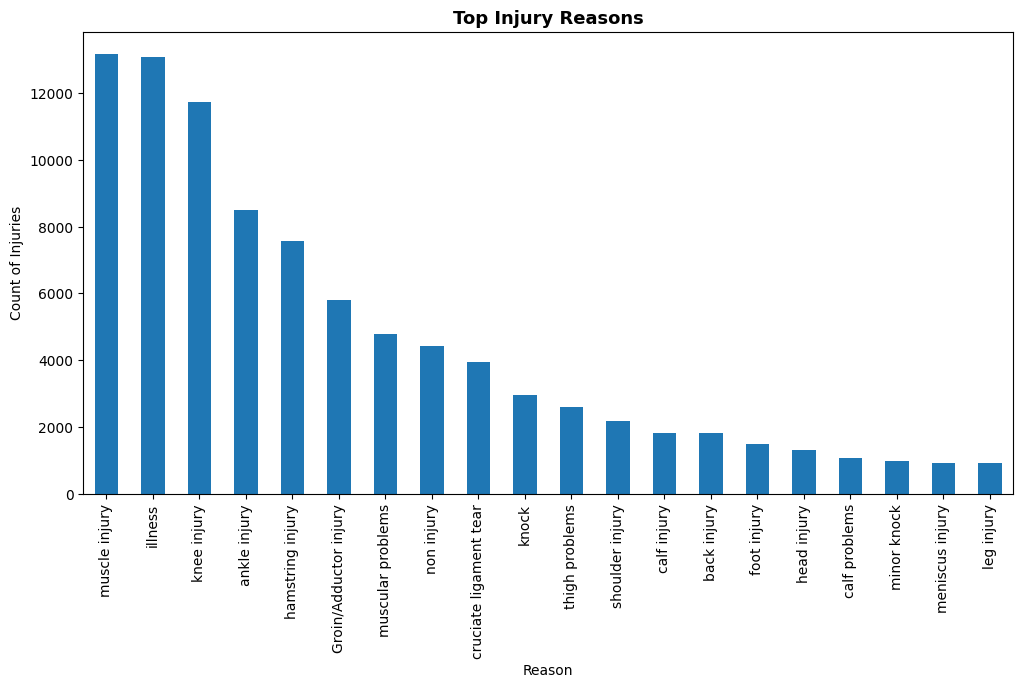

In [17]:
# Plotting the top 10 injury reasons
df[df["injury_clean"] != "Unknown"]["injury_clean"] \
    .value_counts().head(20) \
    .plot(kind='bar')

# Adding labels and title to the plot
plt.title("Top Injury Reasons")
plt.xlabel("Reason")
plt.ylabel("Count of Injuries")
plt.xticks(rotation=90)
plt.show()

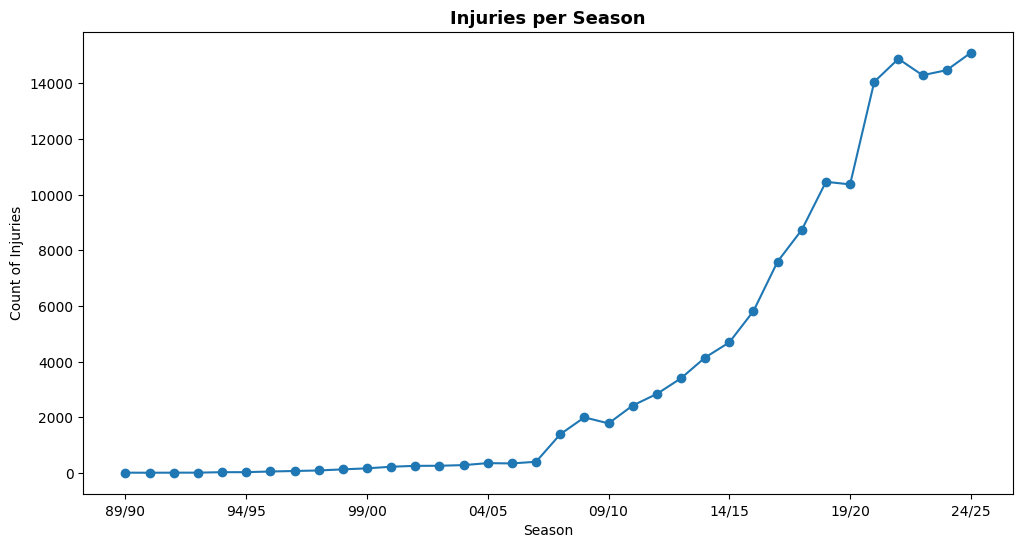

In [18]:
# Plotting the count of injuries per season
df_sorted = df.sort_values("season_sort")
counts = df_sorted.groupby("season_name", sort=False).size()
counts.plot(kind='line', marker='o')

# Adding labels and title to the plot
plt.title("Injuries per Season")
plt.xlabel("Season")
plt.ylabel("Count of Injuries")
plt.xticks(rotation=0)
plt.show()

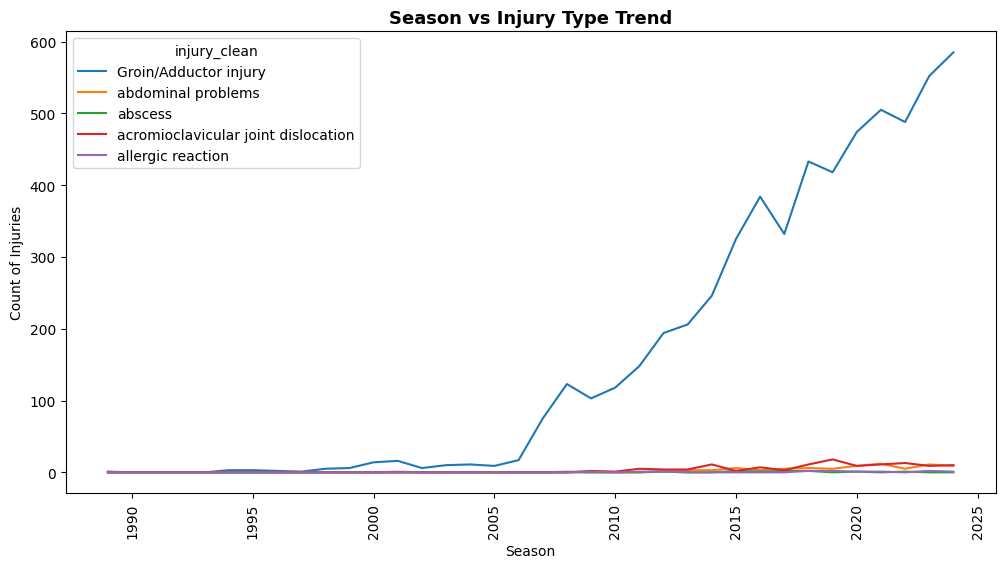

In [19]:
# Plotting the trend of top 5 injury types across seasons
df[df["injury_clean"] != "Unknown"] \
  .groupby(["season_sort", "injury_clean"]) \
  .size() \
  .unstack(fill_value=0) \
  .iloc[:, :5] \
  .plot()

# Adding labels and title to the plot
plt.title("Season vs Injury Type Trend")
plt.xlabel("Season")
plt.ylabel("Count of Injuries")
plt.xticks(rotation=90)
plt.show()

## Day Missed

In [20]:
# Filtering the dataset to exclude outliers based on the IQR method
q1 = df['days_missed'].quantile(0.25)
q3 = df['days_missed'].quantile(0.75)
iqr = q3 - q1


filtered = df[
    (df['days_missed'] >= q1 - 1.5 * iqr) &
    (df['days_missed'] <= q3 + 1.5 * iqr)
]

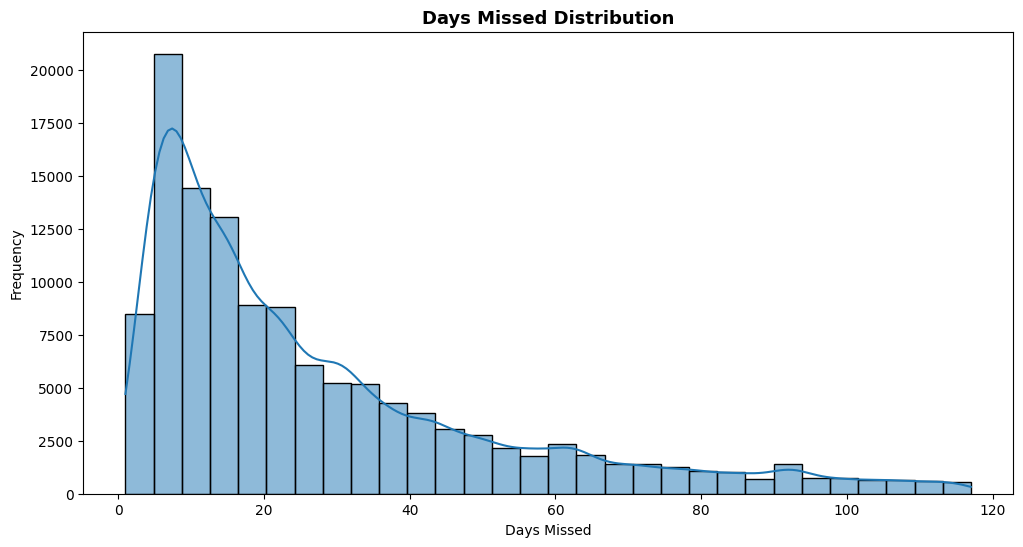

In [21]:
# Plotting the distribution of days missed
sns.histplot(filtered["days_missed"], bins=30, kde=True)
plt.title("Days Missed Distribution")
plt.xlabel("Days Missed")
plt.ylabel("Frequency")
plt.show()

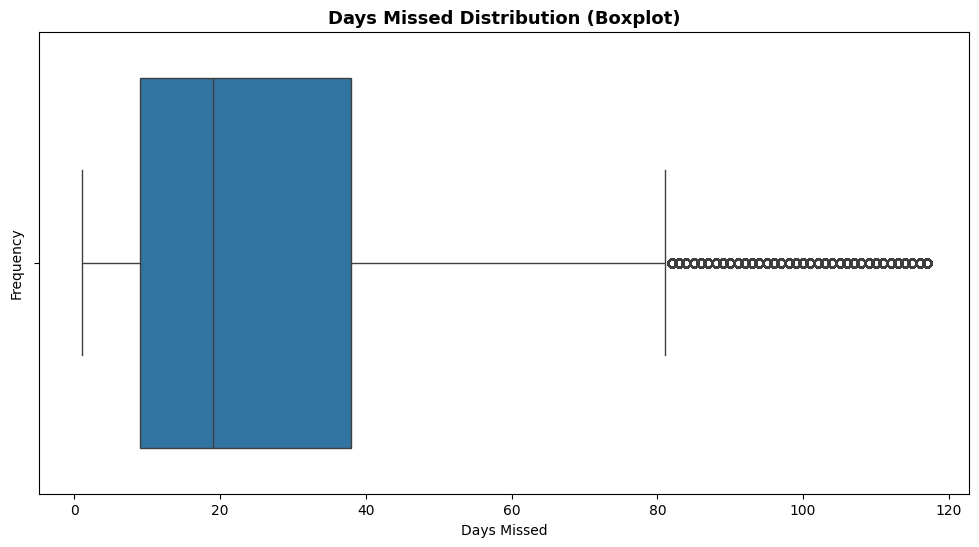

In [22]:
# Plotting the distribution of days missed using a boxplot
sns.boxplot(x=filtered["days_missed"])
plt.title("Days Missed Distribution (Boxplot)")
plt.xlabel("Days Missed")
plt.ylabel("Frequency")
plt.show()

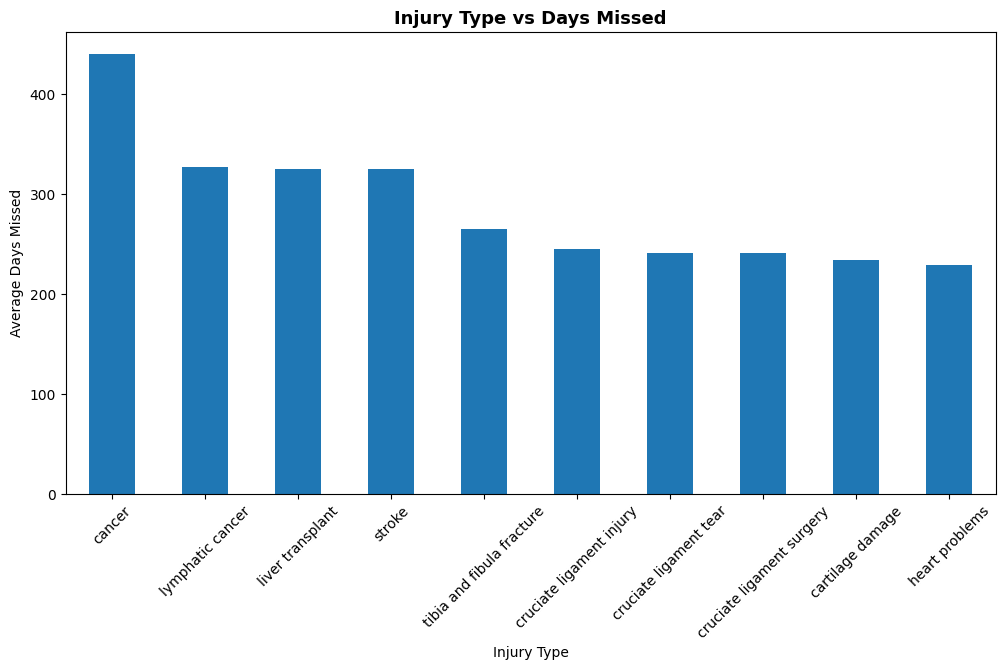

In [23]:
df.groupby("injury_clean")["days_missed"] \
  .mean().sort_values(ascending=False).head(10).plot(kind='bar')

plt.title("Injury Type vs Days Missed")
plt.xlabel("Injury Type")
plt.ylabel("Average Days Missed")
plt.xticks(rotation=45)
plt.show()

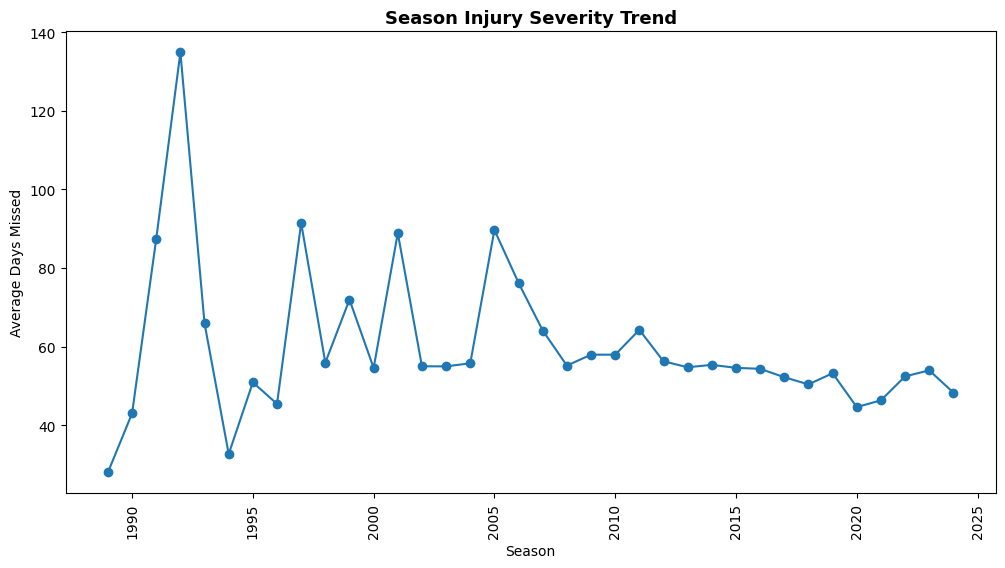

In [24]:
# Plotting the average days missed per season
df.groupby("season_sort")["days_missed"].mean().plot(marker='o')
plt.title("Season Injury Severity Trend")
plt.xlabel("Season")
plt.ylabel("Average Days Missed")
plt.xticks(rotation=90)
plt.show()

## Games Missed

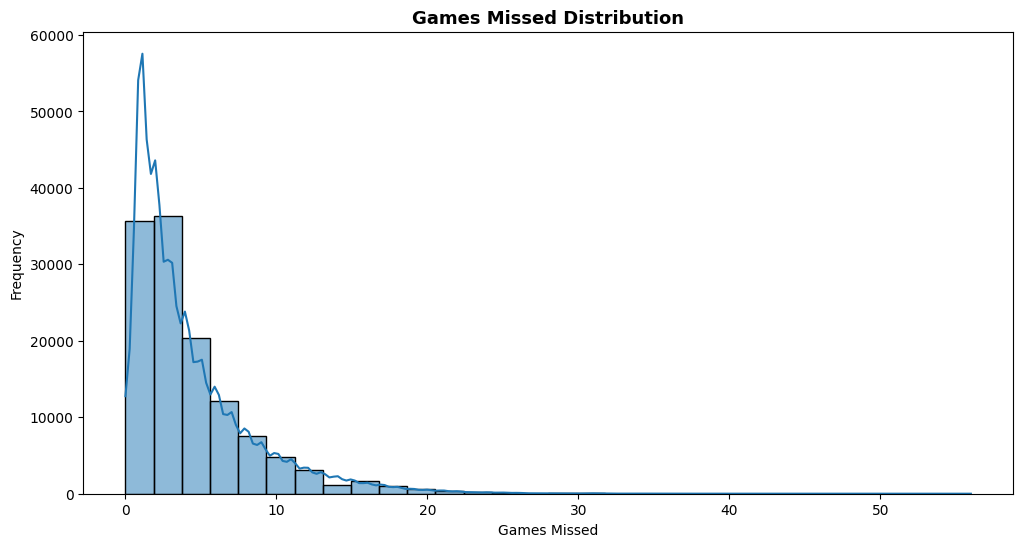

In [25]:
# Plotting the distribution of games missed
sns.histplot(filtered["games_missed"], bins=30, kde=True)
plt.title("Games Missed Distribution")
plt.xlabel("Games Missed")
plt.ylabel("Frequency")
plt.show()

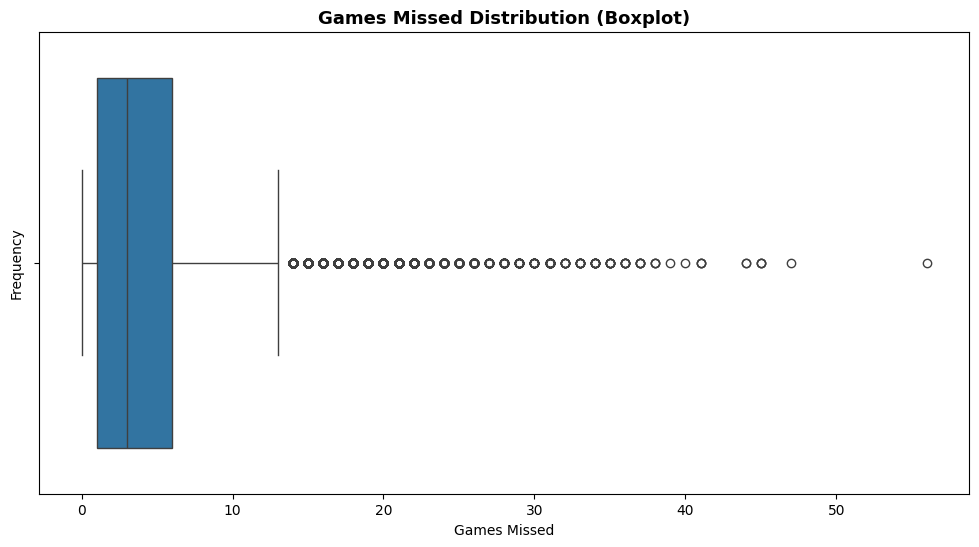

In [26]:
# Plotting the distribution of days missed using a boxplot
sns.boxplot(x=filtered["games_missed"])
plt.title("Games Missed Distribution (Boxplot)")
plt.xlabel("Games Missed")
plt.ylabel("Frequency")
plt.show()

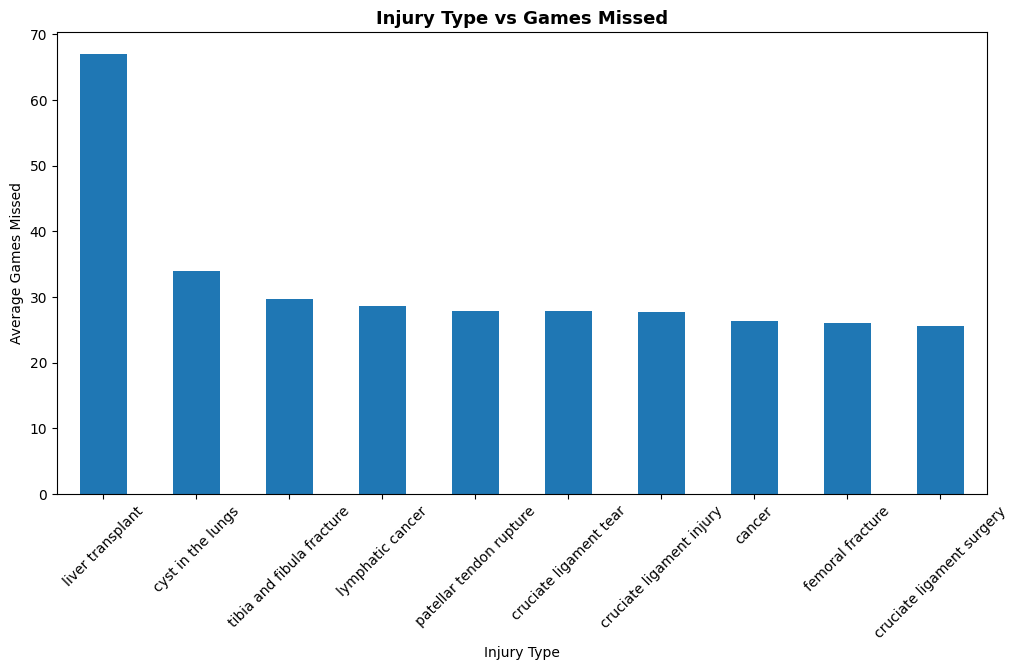

In [27]:
# Plotting the top 10 injury types by average games missed
df.groupby("injury_clean")["games_missed"] \
  .mean().sort_values(ascending=False).head(10).plot(kind='bar')

plt.title("Injury Type vs Games Missed")
plt.xlabel("Injury Type")
plt.ylabel("Average Games Missed")
plt.xticks(rotation=45)
plt.show()

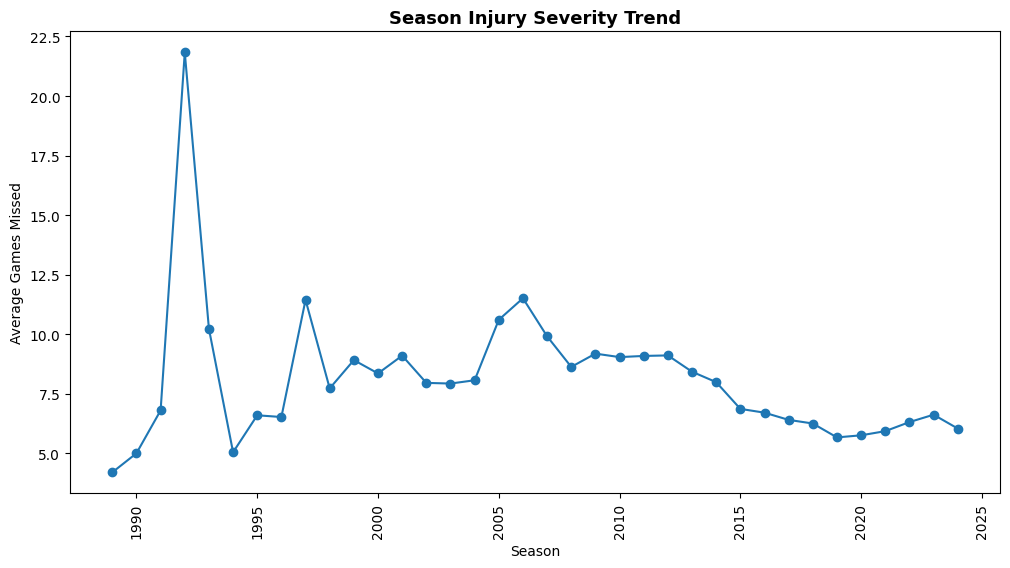

In [28]:
# Plotting the average games missed per season
df.groupby("season_sort")["games_missed"].mean().plot(marker='o')
plt.title("Season Injury Severity Trend")
plt.xlabel("Season")
plt.ylabel("Average Games Missed")
plt.xticks(rotation=90)
plt.show()

## Timeline Analysis

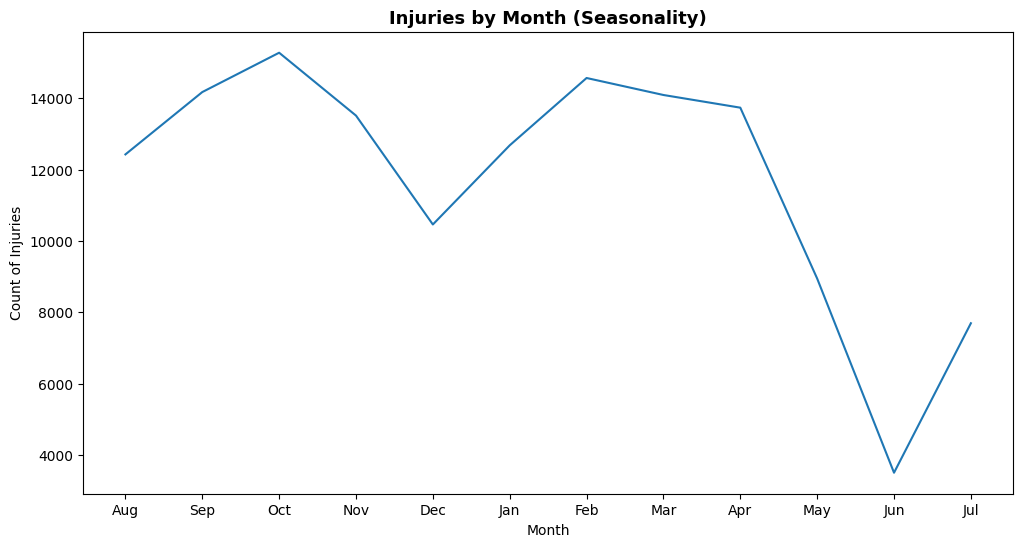

In [29]:
import calendar

# Create month column
df["month"] = df["from_date"].dt.month

# Convert to categorical with custom order
month_order = [8, 9, 10, 11, 12, 1, 2, 3, 4, 5, 6, 7]
df["month"] = pd.Categorical(df["month"], categories=month_order, ordered=True)

# Plot
df.groupby("month").size().plot()
month_names = [calendar.month_abbr[m] for m in month_order]

# Adding labels and title to the plot
plt.xticks(ticks=range(len(month_order)), labels=month_names)
plt.title("Injuries by Month (Seasonality)")
plt.xlabel("Month")
plt.ylabel("Count of Injuries")
plt.show()

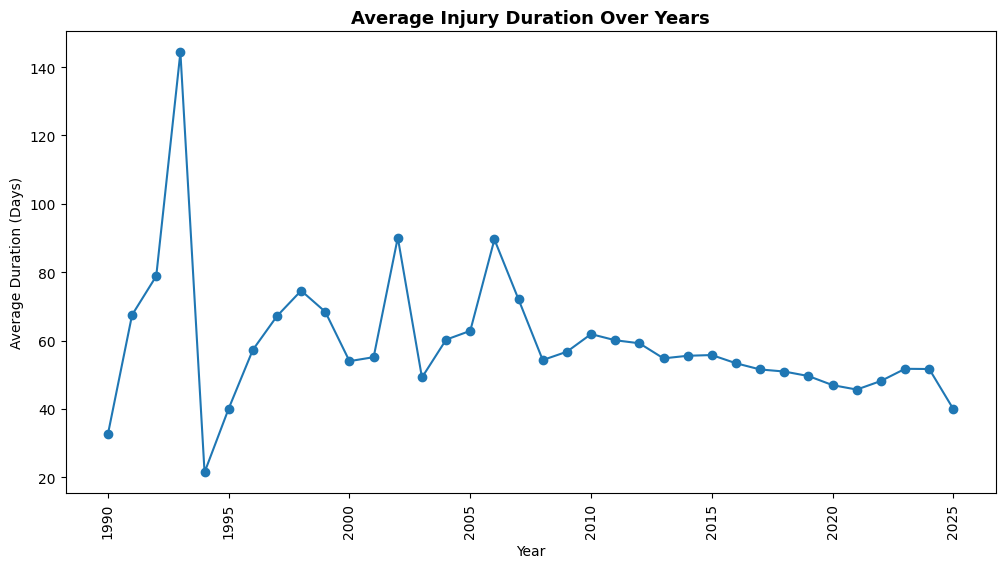

In [30]:
# Plotting the average injury duration over years
df["duration"] = (df["end_date"] - df["from_date"]).dt.days
df.groupby(df["from_date"].dt.year)["duration"].mean().plot(marker='o')
plt.title("Average Injury Duration Over Years")
plt.xlabel("Year")
plt.ylabel("Average Duration (Days)")
plt.xticks(rotation=90)
plt.show()

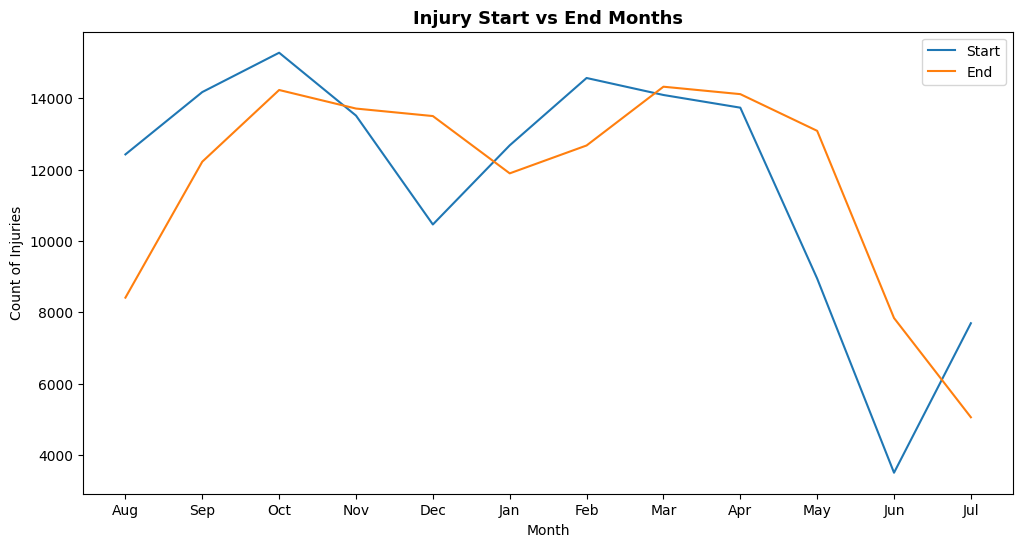

In [31]:
import calendar

# Extract months
df["start_month"] = df["from_date"].dt.month
df["end_month"] = df["end_date"].dt.month

# Custom order (Aug → Jul)
month_order = [8, 9, 10, 11, 12, 1, 2, 3, 4, 5, 6, 7]

# Convert to categorical
df["start_month"] = pd.Categorical(df["start_month"], categories=month_order, ordered=True)
df["end_month"] = pd.Categorical(df["end_month"], categories=month_order, ordered=True)

# Grouping
start_counts = df.groupby("start_month").size()
end_counts = df.groupby("end_month").size()

# Plot
start_counts.plot(label="Start")
end_counts.plot(label="End")

# Month labels
month_names = [calendar.month_abbr[m] for m in month_order]
plt.xticks(ticks=range(len(month_order)), labels=month_names)

# Titles and labels
plt.title("Injury Start vs End Months")
plt.xlabel("Month")
plt.ylabel("Count of Injuries")
plt.legend()
plt.show()

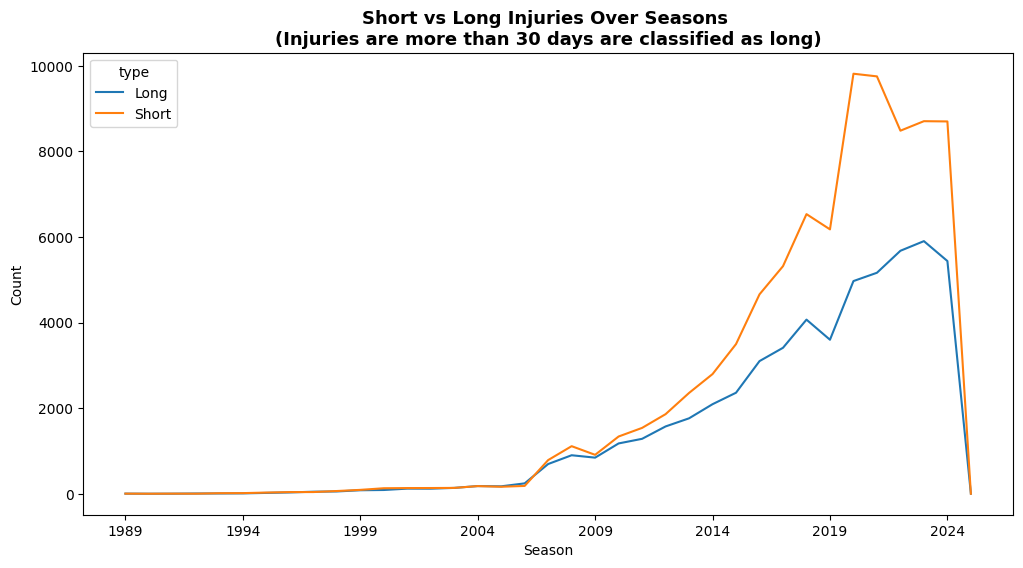

In [32]:
# Duration $ Classify injuries
df["duration"] = (df["end_date"] - df["from_date"]).dt.days
df["type"] = df["duration"].apply(lambda x: "Long" if x > 30 else "Short")

# Create season based on Aug → Jul
df["season"] = df["from_date"].dt.year
df.loc[df["from_date"].dt.month < 8, "season"] -= 1
df["season"] = df["season"].astype(str)

# Group and plot
df.groupby(["season", "type"]).size() \
  .unstack(fill_value=0) \
  .plot()

# Adding labels and title to the plot
plt.title("Short vs Long Injuries Over Seasons \n(Injuries are more than 30 days are classified as long)")
plt.xlabel("Season")
plt.ylabel("Count")
plt.show()

# Predection (ML Modeling)

## Regression Models

In [33]:
df.info()

<class 'pandas.DataFrame'>
Index: 141051 entries, 0 to 143194
Data columns (total 15 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   player_id      141051 non-null  int64         
 1   season_name    141051 non-null  str           
 2   injury_reason  141051 non-null  str           
 3   from_date      141051 non-null  datetime64[us]
 4   end_date       141051 non-null  datetime64[us]
 5   days_missed    141051 non-null  float64       
 6   games_missed   141051 non-null  int64         
 7   season_sort    141051 non-null  int64         
 8   injury_clean   141051 non-null  str           
 9   month          141051 non-null  category      
 10  duration       141051 non-null  int64         
 11  start_month    141051 non-null  category      
 12  end_month      141051 non-null  category      
 13  type           141051 non-null  str           
 14  season         141051 non-null  str           
dtypes: category(3), 

In [34]:
# Dropping columns that are not needed for modeling
drop_cols = [
    "days_missed",   # target
    "from_date",
    "end_date"
]

In [35]:
# Creating new features based on the date columns
df["injury_duration"] = (df["end_date"] - df["from_date"]).dt.days
df["injury_month"] = df["from_date"].dt.month
df["injury_dayofweek"] = df["from_date"].dt.dayofweek

In [36]:
# Calculating player-level average games missed and injury duration
player_stats = df.groupby("player_id").agg({
    "games_missed": "mean",
    "injury_duration": "mean"
}).rename(columns={
    "games_missed": "player_avg_games_missed",
    "injury_duration": "player_avg_injury_duration"
})

# Merging player-level stats back to the main dataframe
df = df.merge(player_stats, on="player_id", how="left")
df["injury_count_player"] = df.groupby("player_id").cumcount()

In [37]:
from sklearn.preprocessing import LabelEncoder

# Encoding categorical variables using LabelEncoder
cat_cols = ["injury_reason", "injury_clean", "type", "season_name"]
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

In [38]:
from sklearn.model_selection import train_test_split

# Preparing the data for modeling
X = df.drop(columns=["days_missed"])
y = df["days_missed"]

# Splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [39]:
from xgboost import XGBRegressor
from sklearn.preprocessing import LabelEncoder

# 1) Copy data
X_train_mod = X_train.copy()
X_test_mod = X_test.copy()

# 2) Handle datetime columns
for df_ in [X_train_mod, X_test_mod]:
    if "from_date" in df_.columns:
        df_["injury_month"] = df_["from_date"].dt.month
        df_["injury_day"] = df_["from_date"].dt.day
        df_.drop(columns=["from_date"], inplace=True)

    if "end_date" in df_.columns:
        df_["end_month"] = df_["end_date"].dt.month
        df_.drop(columns=["end_date"], inplace=True)

# 3) Encode categorical columns
cat_cols = X_train_mod.select_dtypes(include=["object", "category"]).columns
encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    X_train_mod[col] = le.fit_transform(X_train_mod[col].astype(str))
    X_test_mod[col] = le.transform(X_test_mod[col].astype(str))
    encoders[col] = le

# 4) Ensure all data numeric
print(X_train_mod.dtypes)

# 5) Model
model = XGBRegressor(
    n_estimators=800,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.5,
    reg_lambda=1.5,
    min_child_weight=5,
    random_state=42
)

# 6) Fit & Predict
model.fit(X_train_mod, y_train)
preds = model.predict(X_test_mod)

# Fitting the model to the training data
model.fit(X_train_mod, y_train)
preds = model.predict(X_test_mod)

/tmp/ipykernel_198456/592649063.py:20: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train_mod.select_dtypes(include=["object", "category"]).columns


player_id                       int64
season_name                     int64
injury_reason                   int64
games_missed                    int64
season_sort                     int64
injury_clean                    int64
month                           int64
duration                        int64
start_month                     int64
end_month                       int32
type                            int64
season                          int64
injury_duration                 int64
injury_month                    int32
injury_dayofweek                int32
player_avg_games_missed       float64
player_avg_injury_duration    float64
injury_count_player             int64
injury_day                      int32
dtype: object


In [42]:
# Dropping columns that are not needed for modeling
leakage_cols = ["injury_duration", "games_missed", "duration", "player_id"]
X_train_mod = X_train_mod.drop(columns=leakage_cols)
X_test_mod = X_test_mod.drop(columns=leakage_cols)

In [43]:
# Model Initialization
model.fit(X_train_mod, y_train)
preds = model.predict(X_test_mod)

In [44]:
# Evaluating the model
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Calculating MAE and RMSE
mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))

# Printing the evaluation results
print("MAE:", mae)
print("RMSE:", rmse)

MAE: 13.147062820371621
RMSE: 48.86208761060873


In [45]:
# Feature Importance
importance = pd.Series(model.feature_importances_, index=X_train_mod.columns)
importance = importance.sort_values(ascending=False)
print(importance.head(10))

type                          0.357165
player_avg_injury_duration    0.138495
season_name                   0.103155
end_month                     0.062530
season_sort                   0.055675
season                        0.050205
injury_count_player           0.045102
player_avg_games_missed       0.037690
injury_month                  0.028503
injury_reason                 0.026227
dtype: float32


In [47]:
# Adding errors to the test set for analysis
errors = abs(y_test - preds)
X_test_mod["error"] = errors
X_test_mod.sort_values("error", ascending=False).head(10)

,season_name,injury_reason,season_sort,injury_clean,month,start_month,end_month,type,season,injury_month,injury_dayofweek,player_avg_games_missed,player_avg_injury_duration,injury_count_player,injury_day,error
116642,5,178,2005,146,6,6,7,0,16,4,5,0.000000,5581.000000,0,1,4161.249878
985,1,343,2001,231,10,10,9,1,12,8,0,22.200000,1768.800000,1,27,2094.898682
986,0,205,2000,171,9,9,9,0,10,7,4,22.200000,1768.800000,2,28,1771.116699
33423,18,12,2018,7,9,9,9,0,28,7,5,7.666667,679.333333,1,7,1733.685181
106953,17,184,2017,149,9,9,9,0,27,7,6,15.000000,853.666667,2,23,1381.942749
138576,20,12,2020,7,2,2,9,0,31,11,2,26.625000,324.375000,0,25,1353.128357
24217,20,186,2020,149,4,4,9,0,31,2,3,10.375000,292.750000,0,18,1107.569763
2974,21,348,2021,1,4,4,9,0,32,2,4,11.625000,238.625000,0,25,946.141998
50288,15,47,2015,34,7,7,9,0,26,5,6,47.000000,460.000000,0,29,872.144043
23260,19,92,2019,78,4,4,9,0,30,2,4,54.000000,1205.000000,0,14,816.948730


In [51]:
# Clipping the player_avg_injury_duration to a reasonable range (0 to 365 days)
cols_to_clip = [
    "player_avg_injury_duration",
    "player_avg_games_missed"
]

for col in cols_to_clip:
    X_train_mod[col] = X_train_mod[col].clip(0, 365)
    X_test_mod[col] = X_test_mod[col].clip(0, 365)

In [52]:
# Log-transforming the target variable to handle skewness and improve model performance
y_train_log = np.log1p(y_train)

In [53]:
from xgboost import XGBRegressor

# Model Initialization
model = XGBRegressor(
    n_estimators=800,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.5,
    reg_lambda=1.5,
    min_child_weight=5,
    random_state=42
)

# Fitting the model to the training data
model.fit(X_train_mod, y_train_log)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [56]:
# Predicting and inverse transforming the predictions to get back to the original scale
X_test_clean = X_test_mod.drop(columns=["error"])
preds_log = model.predict(X_test_clean)
preds = np.expm1(preds_log)

In [57]:
# Evaluating the model
mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))

# Printing the evaluation results
print("MAE:", mae)
print("RMSE:", rmse)

MAE: 12.021805204979552
RMSE: 59.586692347070596


In [58]:
# Adding errors to the test set for analysis
X_test_mod["error"] = abs(y_test - preds)
X_test_mod.sort_values("error", ascending=False).head(10)

,season_name,injury_reason,season_sort,injury_clean,month,start_month,end_month,type,season,injury_month,injury_dayofweek,player_avg_games_missed,player_avg_injury_duration,injury_count_player,injury_day,error
116642,5,178,2005,146,6,6,7,0,16,4,5,0.000000,365.000,0,1,5296.762421
37189,16,326,2016,119,11,11,9,0,27,9,4,11.571429,365.000,0,30,2935.144684
25417,17,290,2017,149,2,2,9,0,28,11,0,0.000000,365.000,0,6,2424.762848
126716,19,348,2019,1,11,11,9,0,30,9,6,15.000000,365.000,0,15,1910.884857
82135,19,61,2019,45,1,1,9,0,30,10,3,25.000000,365.000,0,24,1770.747314
23260,19,92,2019,78,4,4,9,0,30,2,4,54.000000,365.000,0,14,1647.781189
138576,20,12,2020,7,2,2,9,0,31,11,2,26.625000,324.375,0,25,1411.955841
24217,20,186,2020,149,4,4,9,0,31,2,3,10.375000,292.750,0,18,1372.651245
33150,20,7,2020,130,0,0,9,0,31,1,6,30.000000,365.000,0,10,1309.448120
114917,21,348,2021,1,9,9,9,0,31,7,5,10.500000,365.000,0,3,1251.246063


## Classifiaction

In [62]:
# Classifying injuries based on duration
def injury_class(x):
    if x <= 7:
        return 0   # Short
    elif x <= 30:
        return 1   # Medium
    elif x <= 90:
        return 2   # Long
    else:
        return 3   # Outlier

In [63]:
# Applying the injury classification to the target variable
y_train_cls = y_train.apply(injury_class)
y_test_cls = y_test.apply(injury_class)

In [64]:
from xgboost import XGBClassifier

# Model Initialization
model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# Fitting the model to the training data
model.fit(X_train_mod, y_train_cls)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

In [67]:
# Predicting the classes for the test set
X_test_clean = X_test_mod.drop(columns=["error"], errors="ignore")
y_pred_cls = model.predict(X_test_clean)

In [68]:
from sklearn.metrics import classification_report, confusion_matrix

# Evaluating the classification model
print(classification_report(y_test_cls, y_pred_cls))
print(confusion_matrix(y_test_cls, y_pred_cls))

              precision    recall  f1-score   support

           0       0.75      0.41      0.53      4437
           1       0.80      0.95      0.87     12243
           2       0.96      0.93      0.95      7278
           3       0.96      0.93      0.94      4253

    accuracy                           0.86     28211
   macro avg       0.87      0.81      0.82     28211
weighted avg       0.86      0.86      0.85     28211

[[ 1839  2597     1     0]
 [  600 11643     0     0]
 [    0   326  6796   156]
 [    0     0   306  3947]]


In [70]:
# Checking the distribution of the injury classes in the training set
y_train_cls.value_counts(normalize=True)

days_missed
1    0.437797
2    0.254803
0    0.158454
3    0.148945
Name: proportion, dtype: float64

In [75]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

In [76]:
from sklearn.utils.class_weight import compute_class_weight
classes = np.unique(y_train_cls)

# Computing class weights to handle class imbalance
weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_cls
)

# Mapping class weights to the training labels
class_weights = dict(zip(classes, weights))
sample_weights = y_train_cls.map(class_weights)

In [77]:
# Fitting the model to the training data with sample weights
model.fit(
    X_train_mod,
    y_train_cls,
    sample_weight=sample_weights
)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

In [79]:
# Predicting the classes for the test set
y_pred_cls = model.predict(X_test_clean)

In [80]:
from sklearn.metrics import classification_report

# Evaluating the classification model
print(classification_report(y_test_cls, y_pred_cls))

              precision    recall  f1-score   support

           0       0.53      0.76      0.62      4437
           1       0.87      0.75      0.81     12243
           2       0.97      0.92      0.94      7278
           3       0.94      0.95      0.95      4253

    accuracy                           0.83     28211
   macro avg       0.83      0.85      0.83     28211
weighted avg       0.85      0.83      0.83     28211



In [82]:
# Creating a results dataframe to analyze the predictions
results = X_test_mod.copy()
results["true"] = y_test_cls
results["pred"] = y_pred_cls
results["correct"] = results["true"] == results["pred"]

<Axes: >

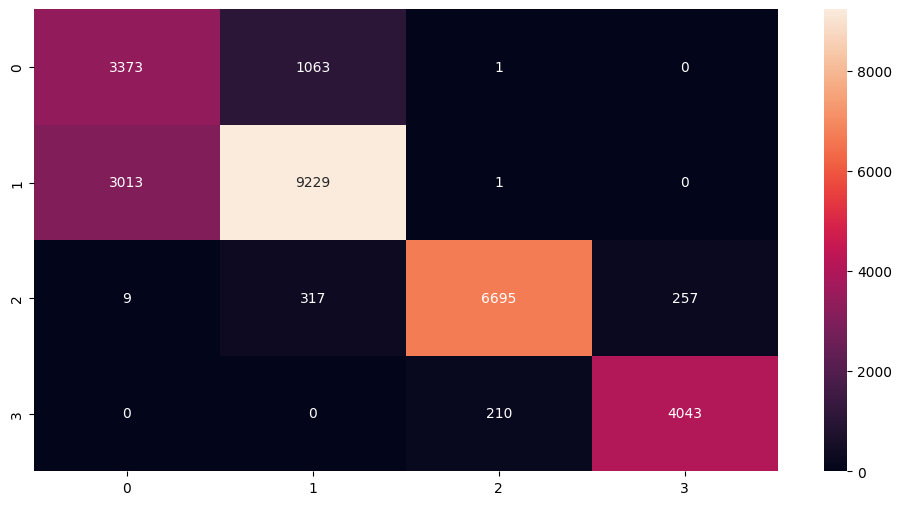

In [83]:
from sklearn.metrics import confusion_matrix

# Plotting the confusion matrix
cm = confusion_matrix(y_test_cls, y_pred_cls)
sns.heatmap(cm, annot=True, fmt="d")

In [85]:
results.groupby("type")["correct"].mean()
results.groupby("season")["correct"].mean()

season
0     1.000000
1     1.000000
2     1.000000
3     1.000000
4     0.888889
5     1.000000
6     0.800000
7     0.666667
8     0.916667
9     0.965517
10    0.909091
11    0.918367
12    0.977778
13    0.815789
14    0.892857
15    0.842857
16    0.797297
17    0.913043
18    0.837288
19    0.848485
20    0.887399
21    0.849237
22    0.819964
23    0.850291
24    0.831579
25    0.854719
26    0.821277
27    0.835850
28    0.809080
29    0.806638
30    0.810407
31    0.825897
32    0.820363
33    0.809134
34    0.842795
35    0.834050
Name: correct, dtype: float64

In [89]:
confusion_01 = results[
    (results["true"] == 0) & (results["pred"] == 1)
]

confusion_01.describe()

,season_name,injury_reason,season_sort,injury_clean,month,start_month,end_month,type,season,injury_month,injury_dayofweek,player_avg_games_missed,player_avg_injury_duration,injury_count_player,injury_day,error,true,pred
count,1063.000000,1063.000000,1063.000000,1063.000000,1063.000000,1063.000000,1063.000000,1063.0,1063.000000,1063.000000,1063.000000,1063.000000,1063.000000,1063.000000,1063.000000,1063.000000,1063.0,1063.0
mean,18.355597,210.925682,2018.118532,93.349953,4.912512,4.912512,6.521167,1.0,29.088429,6.415804,2.708373,5.544888,38.394324,3.885230,13.883349,6.498402,0.0,1.0
std,4.609985,118.135879,4.844189,83.713595,3.404172,3.404172,3.619532,0.0,4.839193,3.612884,2.139133,4.053758,32.797454,3.703716,9.988107,2.301564,0.0,0.0
min,0.000000,0.000000,1993.000000,0.000000,0.000000,0.000000,1.000000,1.0,4.000000,1.000000,0.000000,0.500000,6.666667,0.000000,1.000000,0.628007,0.0,1.0
25%,16.000000,117.000000,2016.000000,1.000000,2.000000,2.000000,3.000000,1.0,27.000000,3.000000,0.000000,3.133333,20.269697,1.000000,5.000000,4.863444,0.0,1.0
50%,19.000000,216.000000,2019.000000,115.000000,5.000000,5.000000,6.000000,1.0,30.000000,7.000000,3.000000,4.500000,29.266667,3.000000,11.000000,6.439061,0.0,1.0
75%,22.000000,343.000000,2022.000000,180.000000,7.000000,7.000000,10.000000,1.0,33.000000,10.000000,5.000000,6.859091,45.191667,6.000000,25.000000,7.925423,0.0,1.0
max,33.000000,348.000000,2024.000000,259.000000,11.000000,11.000000,12.000000,1.0,35.000000,12.000000,6.000000,45.000000,365.000000,14.000000,31.000000,15.472071,0.0,1.0


In [90]:
confusion_10 = results[
    (results["true"] == 1) & (results["pred"] == 0)
]

confusion_10.describe()

,season_name,injury_reason,season_sort,injury_clean,month,start_month,end_month,type,season,injury_month,injury_dayofweek,player_avg_games_missed,player_avg_injury_duration,injury_count_player,injury_day,error,true,pred
count,3013.000000,3013.000000,3013.000000,3013.000000,3013.000000,3013.000000,3013.000000,3013.0,3013.000000,3013.000000,3013.000000,3013.000000,3013.000000,3013.000000,3013.000000,3013.000000,3013.0,3013.0
mean,19.023565,235.935280,2018.987720,100.798872,4.772652,4.772652,6.217391,1.0,29.966147,6.138732,3.006638,4.358575,29.540097,4.738467,13.565217,3.934052,1.0,0.0
std,4.135059,111.856049,4.163912,78.838080,3.292072,3.292072,3.781227,0.0,4.173549,3.780411,1.830633,3.134104,24.935756,3.724489,8.199546,3.836780,0.0,0.0
min,0.000000,1.000000,1996.000000,0.000000,0.000000,0.000000,1.000000,1.0,7.000000,1.000000,0.000000,0.000000,3.400000,0.000000,1.000000,0.002761,1.0,0.0
25%,17.000000,152.000000,2017.000000,1.000000,2.000000,2.000000,3.000000,1.0,28.000000,3.000000,2.000000,2.444444,15.000000,2.000000,7.000000,1.240693,1.0,0.0
50%,20.000000,269.000000,2020.000000,130.000000,4.000000,4.000000,5.000000,1.0,31.000000,5.000000,3.000000,3.545455,23.000000,4.000000,13.000000,2.614472,1.0,0.0
75%,22.000000,342.000000,2022.000000,178.000000,7.000000,7.000000,10.000000,1.0,33.000000,10.000000,4.000000,5.250000,35.000000,7.000000,19.000000,5.338056,1.0,0.0
max,35.000000,348.000000,2024.000000,259.000000,11.000000,11.000000,12.000000,1.0,35.000000,12.000000,6.000000,46.000000,324.375000,14.000000,31.000000,24.427071,1.0,0.0
